# Conformal Prediction: Finite-Sample Prediction Sets and Intervals

This notebook provides a comprehensive introduction to conformal prediction, a framework for generating prediction sets/intervals with finite-sample coverage guarantees.

---

## Learning Objectives

By the end of this notebook, you will be able to:
1. Understand the theoretical foundations: exchangeability, finite-sample guarantees
2. Implement split conformal prediction for classification and regression
3. Apply APS/RAPS methods for efficient prediction sets
4. Extend conformal prediction to object detection and LLM outputs
5. Analyze coverage-efficiency tradeoffs

---

## References

This notebook is inspired by and references:
- **Official Repository**: [github.com/aangelopoulos/conformal-prediction](https://github.com/aangelopoulos/conformal-prediction)
- Angelopoulos & Bates, "A Gentle Introduction to Conformal Prediction and Distribution-Free Uncertainty Quantification", 2021
- Romano, Patterson, Candès, "Conformalized Quantile Regression", NeurIPS 2019
- Angelopoulos et al., "Uncertainty Sets for Image Classifiers using Conformal Prediction", ICLR 2021

In [1]:
# Standard imports and reproducibility setup
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Plotting style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 10

print("Setup complete. Random seed:", RANDOM_SEED)

Setup complete. Random seed: 42


---

# Part 1: Theoretical Foundations

## What is Conformal Prediction?

Conformal prediction is a framework for creating **prediction sets** (for classification) or **prediction intervals** (for regression) that come with **finite-sample, distribution-free coverage guarantees**.

### The Coverage Guarantee

Given a desired coverage level $1 - \alpha$ (e.g., 90%), conformal prediction constructs sets $\mathcal{C}(X_{n+1})$ such that:

$$P(Y_{n+1} \in \mathcal{C}(X_{n+1})) \geq 1 - \alpha$$

This guarantee holds:
- **Without assumptions** on the data distribution (distribution-free)
- **With finite samples** (not just asymptotically)
- **For any black-box model** (model-agnostic)

## Key Assumption: Exchangeability

The main requirement is that the calibration data and test point are **exchangeable**:

$$P((X_1, Y_1), ..., (X_n, Y_n), (X_{n+1}, Y_{n+1})) = P((X_{\pi(1)}, Y_{\pi(1)}), ..., (X_{\pi(n+1)}, Y_{\pi(n+1)}))$$

for any permutation $\pi$. This is weaker than i.i.d. and allows for:
- Stratified sampling
- Certain time-series structures

**Note**: Exchangeability breaks under distribution shift!

## The Conformal Quantile

Given $n$ calibration scores $s_1, ..., s_n$ and a new score $s_{n+1}$, the key insight is:

Under exchangeability, the rank of $s_{n+1}$ among $\{s_1, ..., s_n, s_{n+1}\}$ is uniformly distributed.

The **conformal quantile** (threshold) is computed as:

$$\hat{q} = \text{Quantile}\left(s_1, ..., s_n; \frac{\lceil (n+1)(1-\alpha) \rceil}{n}\right)$$

This is the $\lceil (n+1)(1-\alpha) \rceil$-th smallest value among $n$ scores.

## Marginal vs Conditional Coverage

**Marginal coverage**: The guarantee $P(Y \in \mathcal{C}(X)) \geq 1 - \alpha$ averages over all $X$.

**Conditional coverage**: $P(Y \in \mathcal{C}(X) | X = x) \geq 1 - \alpha$ for each $x$.

⚠️ **Important**: Standard conformal prediction only guarantees marginal coverage. Conditional coverage is impossible to achieve without additional assumptions (Vovk, 2012).

## Efficiency Metrics

Coverage alone is not enough—we want **small** prediction sets:

- **Classification**: Average set size $\frac{1}{n}\sum_i |\mathcal{C}(X_i)|$
- **Regression**: Average interval width $\frac{1}{n}\sum_i (\hat{q}_{hi} - \hat{q}_{lo})$

The ideal is **validity** (correct coverage) + **efficiency** (small sets).

In [2]:
def conformal_quantile(scores, alpha, method='standard'):
    """
    Compute the conformal quantile threshold.
    
    Parameters:
    -----------
    scores : array-like of shape (n,)
        Nonconformity scores from calibration set
    alpha : float
        Desired miscoverage rate (e.g., 0.1 for 90% coverage)
    method : str
        'standard' uses ceil((n+1)(1-alpha))/n quantile
        'conservative' uses (n+1)(1-alpha)/n
    
    Returns:
    --------
    float : The quantile threshold
    """
    n = len(scores)
    if method == 'standard':
        # This gives exact 1-alpha coverage guarantee
        q_level = np.ceil((n + 1) * (1 - alpha)) / n
    else:
        q_level = (n + 1) * (1 - alpha) / n
    
    q_level = min(q_level, 1.0)  # Cap at 1.0
    return np.quantile(scores, q_level, method='higher')


# Demonstrate the conformal quantile
print("=" * 60)
print("Demonstration: Conformal Quantile Computation")
print("=" * 60)

n_cal = 100
alpha = 0.1  # 90% coverage

# Simulate some nonconformity scores
np.random.seed(RANDOM_SEED)
cal_scores = np.random.exponential(1.0, n_cal)

q_hat = conformal_quantile(cal_scores, alpha)
print(f"\nCalibration set size: n = {n_cal}")
print(f"Desired coverage: 1 - α = {1 - alpha:.0%}")
print(f"Quantile level: ceil((n+1)(1-α))/n = ceil({(n_cal+1)*(1-alpha)})/100 = {np.ceil((n_cal+1)*(1-alpha))/n_cal:.3f}")
print(f"Conformal quantile q̂ = {q_hat:.4f}")

# Verify coverage on calibration set (should be >= 1 - alpha)
cal_coverage = np.mean(cal_scores <= q_hat)
print(f"\nEmpirical coverage on calibration set: {cal_coverage:.1%}")

Demonstration: Conformal Quantile Computation

Calibration set size: n = 100
Desired coverage: 1 - α = 90%
Quantile level: ceil((n+1)(1-α))/n = ceil(90.9)/100 = 0.910
Conformal quantile q̂ = 2.4004

Empirical coverage on calibration set: 92.0%


---

# Part 2: Classification Prediction Sets

## Split Conformal for Classification

Given a classifier that outputs class probabilities $\hat{p}(y|x)$ for each class $y \in \{1, ..., K\}$:

### Simple Score: $s(x, y) = 1 - \hat{p}(y|x)$

This score is small when the model is confident in the true class.

**Algorithm (Split Conformal):**
1. Split data into training and calibration sets
2. Train classifier on training set
3. Compute scores $s_i = 1 - \hat{p}(y_i|x_i)$ on calibration set
4. Compute conformal quantile $\hat{q}$
5. For test point $x$, prediction set: $\mathcal{C}(x) = \{y : 1 - \hat{p}(y|x) \leq \hat{q}\}$

Equivalently: $\mathcal{C}(x) = \{y : \hat{p}(y|x) \geq 1 - \hat{q}\}$

In [3]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Load digits dataset
digits = load_digits()
X, y = digits.data, digits.target
n_classes = len(np.unique(y))

print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features, {n_classes} classes")

# Split: 60% train, 20% calibration, 20% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=RANDOM_SEED, stratify=y
)
X_cal, X_test, y_cal, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED, stratify=y_temp
)

print(f"Train: {len(X_train)}, Calibration: {len(X_cal)}, Test: {len(X_test)}")

# Standardize and train classifier
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_cal_scaled = scaler.transform(X_cal)
X_test_scaled = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
clf.fit(X_train_scaled, y_train)

print(f"\nClassifier accuracy: {clf.score(X_test_scaled, y_test):.1%}")

Dataset: 1797 samples, 64 features, 10 classes
Train: 1078, Calibration: 359, Test: 360

Classifier accuracy: 96.4%


In [4]:
def split_conformal_classification(clf, X_cal, y_cal, X_test, alpha):
    """
    Split conformal prediction for classification.
    
    Uses simple score: s(x, y) = 1 - p(y|x)
    
    Parameters:
    -----------
    clf : classifier with predict_proba method
    X_cal : calibration features
    y_cal : calibration labels
    X_test : test features
    alpha : miscoverage rate
    
    Returns:
    --------
    dict with prediction sets, quantile, and scores
    """
    # Get calibration probabilities
    cal_probs = clf.predict_proba(X_cal)
    n_cal = len(y_cal)
    
    # Compute scores: s = 1 - p(true class)
    cal_scores = 1 - cal_probs[np.arange(n_cal), y_cal]
    
    # Compute conformal quantile
    q_hat = conformal_quantile(cal_scores, alpha)
    
    # Get test probabilities
    test_probs = clf.predict_proba(X_test)
    
    # Construct prediction sets: {y : 1 - p(y|x) <= q_hat}
    # Equivalently: {y : p(y|x) >= 1 - q_hat}
    prediction_sets = []
    for probs in test_probs:
        pred_set = np.where(probs >= 1 - q_hat)[0].tolist()
        prediction_sets.append(pred_set)
    
    return {
        'prediction_sets': prediction_sets,
        'q_hat': q_hat,
        'cal_scores': cal_scores,
        'test_probs': test_probs
    }


# Run split conformal
alpha = 0.1  # 90% coverage target
result = split_conformal_classification(clf, X_cal_scaled, y_cal, X_test_scaled, alpha)

print("Split Conformal Classification Results")
print("=" * 50)
print(f"Target coverage: {1 - alpha:.0%}")
print(f"Conformal quantile q̂: {result['q_hat']:.4f}")
print(f"Threshold probability: 1 - q̂ = {1 - result['q_hat']:.4f}")

# Compute coverage and set sizes
coverages = [y_test[i] in result['prediction_sets'][i] for i in range(len(y_test))]
set_sizes = [len(s) for s in result['prediction_sets']]

print(f"\nEmpirical coverage: {np.mean(coverages):.1%}")
print(f"Average set size: {np.mean(set_sizes):.2f}")
print(f"Set size distribution: min={min(set_sizes)}, max={max(set_sizes)}")

Split Conformal Classification Results
Target coverage: 90%
Conformal quantile q̂: 0.2545
Threshold probability: 1 - q̂ = 0.7455

Empirical coverage: 91.4%
Average set size: 0.93
Set size distribution: min=0, max=1


## Adaptive Prediction Sets (APS) and RAPS

The simple score $1 - \hat{p}(y|x)$ can produce large sets when the model is uncertain. **APS** (Adaptive Prediction Sets) uses a cumulative probability score:

### APS Score

Sort classes by decreasing probability: $\hat{p}_{(1)} \geq \hat{p}_{(2)} \geq ... \geq \hat{p}_{(K)}$

The APS score for the true class $y$ (ranked $r_y$) is:

$$s_{APS}(x, y) = \sum_{j=1}^{r_y} \hat{p}_{(j)} + u \cdot \hat{p}_{(r_y)}$$

where $u \sim \text{Uniform}(0, 1)$ is randomization for exact coverage.

### RAPS (Regularized APS)

RAPS adds a penalty to encourage smaller sets:

$$s_{RAPS}(x, y) = s_{APS}(x, y) + \lambda \cdot (r_y - k_{reg})_+$$

where $k_{reg}$ is a regularization parameter (typically the number of classes to allow before penalty).

In [5]:
def compute_aps_score(probs, y_true, randomize=True):
    """
    Compute APS (Adaptive Prediction Sets) score.
    
    Parameters:
    -----------
    probs : array of shape (n_classes,)
        Predicted probabilities for each class
    y_true : int
        True class label
    randomize : bool
        Whether to add randomization for exact coverage
    
    Returns:
    --------
    float : APS score
    """
    # Sort classes by decreasing probability
    sorted_indices = np.argsort(-probs)
    sorted_probs = probs[sorted_indices]
    
    # Find rank of true class (1-indexed)
    rank = np.where(sorted_indices == y_true)[0][0] + 1
    
    # Cumulative sum up to and including true class
    cumsum = np.cumsum(sorted_probs)
    
    if rank == 1:
        score = sorted_probs[0]
    else:
        score = cumsum[rank - 1]
    
    # Add randomization
    if randomize:
        u = np.random.uniform(0, 1)
        score = cumsum[rank - 2] + u * sorted_probs[rank - 1] if rank > 1 else u * sorted_probs[0]
    
    return score


def compute_raps_score(probs, y_true, lambda_reg=0.1, k_reg=3, randomize=True):
    """
    Compute RAPS (Regularized APS) score.
    
    Parameters:
    -----------
    probs : array of shape (n_classes,)
        Predicted probabilities
    y_true : int
        True class label
    lambda_reg : float
        Regularization strength
    k_reg : int
        Number of classes before penalty kicks in
    randomize : bool
        Whether to add randomization
    
    Returns:
    --------
    float : RAPS score
    """
    # Sort classes by decreasing probability
    sorted_indices = np.argsort(-probs)
    sorted_probs = probs[sorted_indices]
    
    # Find rank of true class
    rank = np.where(sorted_indices == y_true)[0][0] + 1
    
    # Compute cumulative sum with regularization penalty
    cumsum = np.cumsum(sorted_probs)
    
    # Base score (cumulative probability)
    if randomize:
        u = np.random.uniform(0, 1)
        base_score = cumsum[rank - 2] + u * sorted_probs[rank - 1] if rank > 1 else u * sorted_probs[0]
    else:
        base_score = cumsum[rank - 1]
    
    # Add regularization penalty
    penalty = lambda_reg * max(0, rank - k_reg)
    
    return base_score + penalty


def aps_conformal_prediction(clf, X_cal, y_cal, X_test, alpha, method='aps', 
                              lambda_reg=0.1, k_reg=3):
    """
    APS/RAPS conformal prediction for classification.
    """
    # Get calibration probabilities
    cal_probs = clf.predict_proba(X_cal)
    n_cal = len(y_cal)
    
    # Compute calibration scores
    cal_scores = []
    for i in range(n_cal):
        if method == 'aps':
            score = compute_aps_score(cal_probs[i], y_cal[i], randomize=True)
        else:  # raps
            score = compute_raps_score(cal_probs[i], y_cal[i], lambda_reg, k_reg, randomize=True)
        cal_scores.append(score)
    cal_scores = np.array(cal_scores)
    
    # Compute conformal quantile
    q_hat = conformal_quantile(cal_scores, alpha)
    
    # Get test probabilities and construct prediction sets
    test_probs = clf.predict_proba(X_test)
    n_classes = test_probs.shape[1]
    
    prediction_sets = []
    for probs in test_probs:
        # Sort by decreasing probability
        sorted_indices = np.argsort(-probs)
        sorted_probs = probs[sorted_indices]
        
        # Add classes until score exceeds threshold
        pred_set = []
        cumsum = 0
        for j, idx in enumerate(sorted_indices):
            cumsum += sorted_probs[j]
            penalty = lambda_reg * max(0, j + 1 - k_reg) if method == 'raps' else 0
            pred_set.append(idx)
            if cumsum + penalty >= q_hat:
                break
        
        prediction_sets.append(pred_set)
    
    return {
        'prediction_sets': prediction_sets,
        'q_hat': q_hat,
        'cal_scores': cal_scores
    }


# Compare methods
print("Comparing Conformal Methods")
print("=" * 60)

methods = {
    'Simple (1-p)': split_conformal_classification(clf, X_cal_scaled, y_cal, X_test_scaled, alpha),
    'APS': aps_conformal_prediction(clf, X_cal_scaled, y_cal, X_test_scaled, alpha, method='aps'),
    'RAPS (λ=0.1)': aps_conformal_prediction(clf, X_cal_scaled, y_cal, X_test_scaled, alpha, 
                                              method='raps', lambda_reg=0.1, k_reg=3)
}

print(f"\n{'Method':<20} {'Coverage':>12} {'Avg Size':>12} {'Max Size':>10}")
print("-" * 60)

for name, res in methods.items():
    coverages = [y_test[i] in res['prediction_sets'][i] for i in range(len(y_test))]
    set_sizes = [len(s) for s in res['prediction_sets']]
    print(f"{name:<20} {np.mean(coverages):>12.1%} {np.mean(set_sizes):>12.2f} {max(set_sizes):>10}")

Comparing Conformal Methods

Method                   Coverage     Avg Size   Max Size
------------------------------------------------------------
Simple (1-p)                91.4%         0.93          1
APS                         99.4%         1.23          5
RAPS (λ=0.1)                99.2%         1.21          4


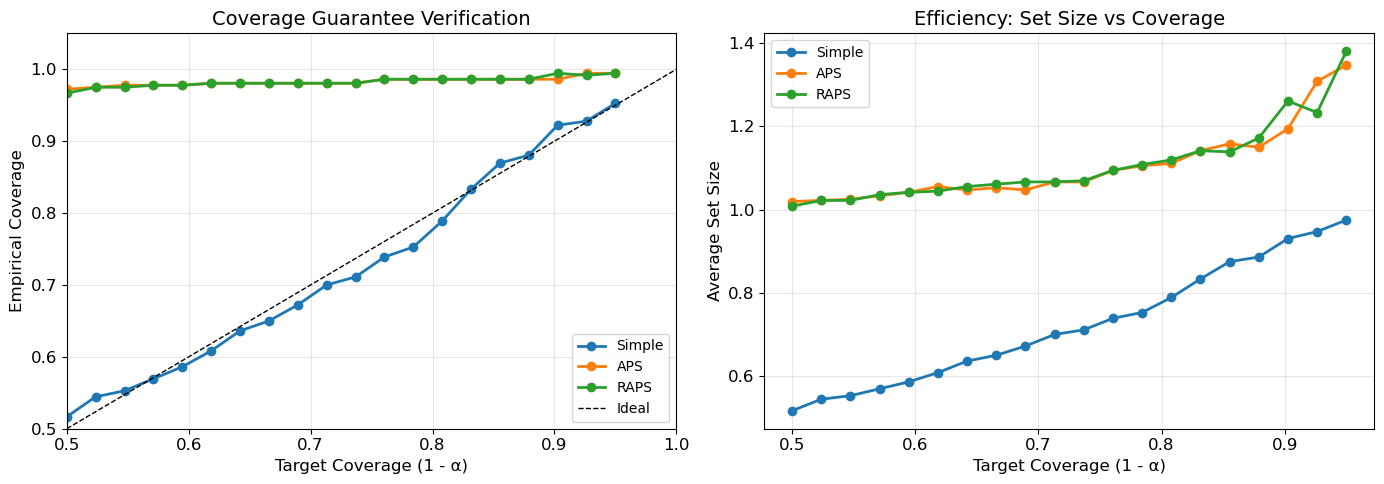


Saved: classification_coverage_curve.png
Saved: classification_setsize_curve.png


In [6]:
# Plot coverage and set size curves across different alpha values
alphas = np.linspace(0.05, 0.5, 20)

coverage_results = {name: [] for name in ['Simple', 'APS', 'RAPS']}
setsize_results = {name: [] for name in ['Simple', 'APS', 'RAPS']}

for alpha_val in alphas:
    # Simple
    res = split_conformal_classification(clf, X_cal_scaled, y_cal, X_test_scaled, alpha_val)
    cov = np.mean([y_test[i] in res['prediction_sets'][i] for i in range(len(y_test))])
    sizes = np.mean([len(s) for s in res['prediction_sets']])
    coverage_results['Simple'].append(cov)
    setsize_results['Simple'].append(sizes)
    
    # APS
    res = aps_conformal_prediction(clf, X_cal_scaled, y_cal, X_test_scaled, alpha_val, method='aps')
    cov = np.mean([y_test[i] in res['prediction_sets'][i] for i in range(len(y_test))])
    sizes = np.mean([len(s) for s in res['prediction_sets']])
    coverage_results['APS'].append(cov)
    setsize_results['APS'].append(sizes)
    
    # RAPS
    res = aps_conformal_prediction(clf, X_cal_scaled, y_cal, X_test_scaled, alpha_val, 
                                   method='raps', lambda_reg=0.1, k_reg=3)
    cov = np.mean([y_test[i] in res['prediction_sets'][i] for i in range(len(y_test))])
    sizes = np.mean([len(s) for s in res['prediction_sets']])
    coverage_results['RAPS'].append(cov)
    setsize_results['RAPS'].append(sizes)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Simple': 'tab:blue', 'APS': 'tab:orange', 'RAPS': 'tab:green'}

# Coverage plot
ax = axes[0]
for name in coverage_results:
    ax.plot(1 - alphas, coverage_results[name], 'o-', color=colors[name], label=name, linewidth=2)
ax.plot([0.5, 1], [0.5, 1], 'k--', label='Ideal', linewidth=1)
ax.set_xlabel('Target Coverage (1 - α)')
ax.set_ylabel('Empirical Coverage')
ax.set_title('Coverage Guarantee Verification')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim([0.5, 1.0])
ax.set_ylim([0.5, 1.05])

# Set size plot
ax = axes[1]
for name in setsize_results:
    ax.plot(1 - alphas, setsize_results[name], 'o-', color=colors[name], label=name, linewidth=2)
ax.set_xlabel('Target Coverage (1 - α)')
ax.set_ylabel('Average Set Size')
ax.set_title('Efficiency: Set Size vs Coverage')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('classification_coverage_curve.png', dpi=150, bbox_inches='tight')
plt.savefig('classification_setsize_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: classification_coverage_curve.png")
print("Saved: classification_setsize_curve.png")

---

# Part 3: Regression Prediction Intervals

## Split Conformal Residual Intervals

For regression, the simplest approach uses **absolute residuals** as nonconformity scores:

$$s(x, y) = |y - \hat{f}(x)|$$

The prediction interval is:

$$\mathcal{C}(x) = [\hat{f}(x) - \hat{q}, \hat{f}(x) + \hat{q}]$$

**Limitation**: This produces intervals of constant width, regardless of local uncertainty.

## Conformalized Quantile Regression (CQR)

CQR addresses the constant-width limitation by using **quantile regression** to estimate conditional quantiles:

1. Train quantile regressors for $\hat{q}_{\alpha/2}(x)$ (lower) and $\hat{q}_{1-\alpha/2}(x)$ (upper)
2. Compute conformity scores: $s_i = \max(\hat{q}_{lo}(x_i) - y_i, y_i - \hat{q}_{hi}(x_i))$
3. Compute conformal quantile $\hat{q}$
4. Prediction interval: $[\hat{q}_{lo}(x) - \hat{q}, \hat{q}_{hi}(x) + \hat{q}]$

This produces **adaptive intervals** that are wider in uncertain regions.

In [7]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge

# Generate synthetic regression data with heteroscedastic noise
np.random.seed(RANDOM_SEED)
n_samples = 1000

X_reg = np.random.uniform(0, 10, (n_samples, 1))
# Heteroscedastic: noise increases with X
noise_scale = 0.5 + 0.3 * X_reg[:, 0]
y_reg = np.sin(X_reg[:, 0]) + noise_scale * np.random.randn(n_samples)

# Split data
X_train_r, X_temp_r, y_train_r, y_temp_r = train_test_split(
    X_reg, y_reg, test_size=0.4, random_state=RANDOM_SEED
)
X_cal_r, X_test_r, y_cal_r, y_test_r = train_test_split(
    X_temp_r, y_temp_r, test_size=0.5, random_state=RANDOM_SEED
)

print(f"Regression data: Train={len(X_train_r)}, Cal={len(X_cal_r)}, Test={len(X_test_r)}")

Regression data: Train=600, Cal=200, Test=200


In [8]:
def split_conformal_regression(model, X_cal, y_cal, X_test, alpha):
    """
    Split conformal prediction for regression using absolute residuals.
    
    Returns prediction intervals of constant width.
    """
    # Compute calibration residuals
    y_cal_pred = model.predict(X_cal)
    cal_scores = np.abs(y_cal - y_cal_pred)
    
    # Conformal quantile
    q_hat = conformal_quantile(cal_scores, alpha)
    
    # Predict on test set
    y_test_pred = model.predict(X_test)
    
    # Construct intervals
    lower = y_test_pred - q_hat
    upper = y_test_pred + q_hat
    
    return {
        'lower': lower,
        'upper': upper,
        'point_pred': y_test_pred,
        'q_hat': q_hat,
        'cal_scores': cal_scores
    }


def cqr_conformal_regression(X_train, y_train, X_cal, y_cal, X_test, alpha):
    """
    Conformalized Quantile Regression (CQR).
    
    Uses quantile regression for adaptive interval widths.
    """
    # Train quantile regressors
    alpha_lo = alpha / 2
    alpha_hi = 1 - alpha / 2
    
    # Lower quantile regressor
    qr_lo = GradientBoostingRegressor(
        loss='quantile', alpha=alpha_lo, n_estimators=100, 
        max_depth=3, random_state=RANDOM_SEED
    )
    qr_lo.fit(X_train, y_train)
    
    # Upper quantile regressor
    qr_hi = GradientBoostingRegressor(
        loss='quantile', alpha=alpha_hi, n_estimators=100,
        max_depth=3, random_state=RANDOM_SEED
    )
    qr_hi.fit(X_train, y_train)
    
    # Compute conformity scores on calibration set
    cal_lo = qr_lo.predict(X_cal)
    cal_hi = qr_hi.predict(X_cal)
    
    # CQR score: max(lower - y, y - upper)
    cal_scores = np.maximum(cal_lo - y_cal, y_cal - cal_hi)
    
    # Conformal quantile
    q_hat = conformal_quantile(cal_scores, alpha)
    
    # Predict on test set
    test_lo = qr_lo.predict(X_test)
    test_hi = qr_hi.predict(X_test)
    
    # Construct intervals
    lower = test_lo - q_hat
    upper = test_hi + q_hat
    
    return {
        'lower': lower,
        'upper': upper,
        'point_pred': (test_lo + test_hi) / 2,
        'q_hat': q_hat,
        'cal_scores': cal_scores,
        'qr_lo': test_lo,
        'qr_hi': test_hi
    }


# Train a point predictor
reg_model = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=RANDOM_SEED)
reg_model.fit(X_train_r, y_train_r)

# Apply both methods
alpha_reg = 0.1  # 90% coverage

result_split = split_conformal_regression(reg_model, X_cal_r, y_cal_r, X_test_r, alpha_reg)
result_cqr = cqr_conformal_regression(X_train_r, y_train_r, X_cal_r, y_cal_r, X_test_r, alpha_reg)

# Evaluate
def eval_regression_intervals(y_true, lower, upper):
    coverage = np.mean((y_true >= lower) & (y_true <= upper))
    width = np.mean(upper - lower)
    return coverage, width

cov_split, width_split = eval_regression_intervals(y_test_r, result_split['lower'], result_split['upper'])
cov_cqr, width_cqr = eval_regression_intervals(y_test_r, result_cqr['lower'], result_cqr['upper'])

print("Regression Prediction Intervals")
print("=" * 50)
print(f"Target coverage: {1 - alpha_reg:.0%}")
print(f"\n{'Method':<25} {'Coverage':>12} {'Avg Width':>12}")
print("-" * 50)
print(f"{'Split Conformal':<25} {cov_split:>12.1%} {width_split:>12.3f}")
print(f"{'CQR':<25} {cov_cqr:>12.1%} {width_cqr:>12.3f}")

Regression Prediction Intervals
Target coverage: 90%

Method                        Coverage    Avg Width
--------------------------------------------------
Split Conformal                  96.5%        9.319
CQR                              96.0%        6.759


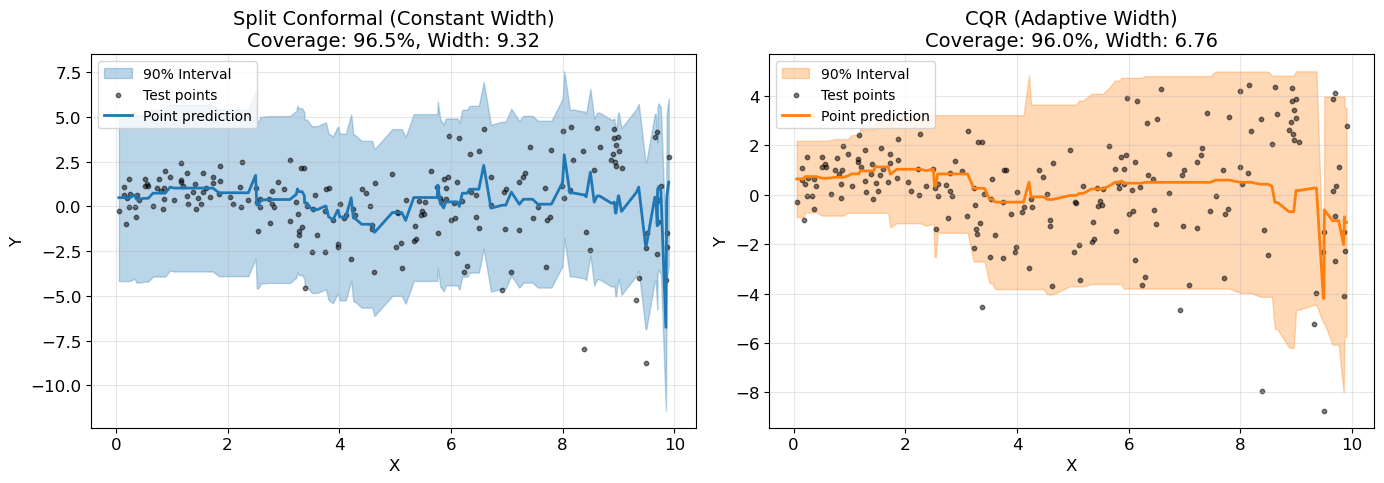


Saved: regression_interval_plot.png

Note: CQR produces wider intervals where noise is higher (right side of plot).


In [9]:
# Plot regression intervals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sort by X for cleaner visualization
sort_idx = np.argsort(X_test_r[:, 0])
X_sorted = X_test_r[sort_idx, 0]
y_sorted = y_test_r[sort_idx]

# Split Conformal
ax = axes[0]
lower_sorted = result_split['lower'][sort_idx]
upper_sorted = result_split['upper'][sort_idx]

ax.fill_between(X_sorted, lower_sorted, upper_sorted, alpha=0.3, color='tab:blue', label='90% Interval')
ax.scatter(X_sorted, y_sorted, s=10, c='black', alpha=0.5, label='Test points')
ax.plot(X_sorted, result_split['point_pred'][sort_idx], 'tab:blue', linewidth=2, label='Point prediction')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title(f'Split Conformal (Constant Width)\nCoverage: {cov_split:.1%}, Width: {width_split:.2f}')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# CQR
ax = axes[1]
lower_sorted = result_cqr['lower'][sort_idx]
upper_sorted = result_cqr['upper'][sort_idx]

ax.fill_between(X_sorted, lower_sorted, upper_sorted, alpha=0.3, color='tab:orange', label='90% Interval')
ax.scatter(X_sorted, y_sorted, s=10, c='black', alpha=0.5, label='Test points')
ax.plot(X_sorted, result_cqr['point_pred'][sort_idx], 'tab:orange', linewidth=2, label='Point prediction')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title(f'CQR (Adaptive Width)\nCoverage: {cov_cqr:.1%}, Width: {width_cqr:.2f}')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('regression_interval_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: regression_interval_plot.png")
print("\nNote: CQR produces wider intervals where noise is higher (right side of plot).")

---

# Part 4: Object Detection Conformal Prediction

Object detection introduces unique challenges:
1. **Multiple objects** per image
2. **Bounding box localization** uncertainty
3. **Matching** predicted boxes to ground truth (IoU-based)

## Conformal Pattern for Detection

For each predicted bounding box with coordinates $(x, y, w, h)$ and confidence $c$:

### Box Expansion Approach

1. Train detector on training set
2. On calibration set, for each matched (pred, gt) pair:
   - Compute expansion factors: $e_x = |x_{gt} - x_{pred}|$, etc.
3. Compute conformal quantiles for each dimension
4. For test predictions, expand boxes by quantile amounts

### Matching with IoU

In a real detector pipeline:
1. Compute IoU matrix between predictions and ground truths
2. Use Hungarian matching or greedy assignment (IoU > threshold)
3. Only matched boxes contribute to calibration

In [10]:
# Synthetic object detection demonstration

def generate_synthetic_detection_data(n_images=100, max_objects=3, seed=42):
    """
    Generate synthetic detection data.
    
    Each box is [x_center, y_center, width, height] normalized to [0, 1].
    """
    np.random.seed(seed)
    
    gt_boxes_list = []
    pred_boxes_list = []
    confidences_list = []
    
    for _ in range(n_images):
        n_objects = np.random.randint(1, max_objects + 1)
        
        # Ground truth boxes
        gt_boxes = []
        pred_boxes = []
        confidences = []
        
        for _ in range(n_objects):
            # Random ground truth box
            x = np.random.uniform(0.1, 0.9)
            y = np.random.uniform(0.1, 0.9)
            w = np.random.uniform(0.1, 0.3)
            h = np.random.uniform(0.1, 0.3)
            gt_boxes.append([x, y, w, h])
            
            # Simulated prediction with noise (heteroscedastic)
            noise_scale = 0.02 + 0.03 * np.random.random()  # Variable noise
            x_pred = x + np.random.normal(0, noise_scale)
            y_pred = y + np.random.normal(0, noise_scale)
            w_pred = w * (1 + np.random.normal(0, 0.1))
            h_pred = h * (1 + np.random.normal(0, 0.1))
            pred_boxes.append([x_pred, y_pred, w_pred, h_pred])
            
            # Confidence (higher for better predictions)
            conf = np.clip(0.9 - noise_scale * 10 + np.random.normal(0, 0.1), 0.3, 0.99)
            confidences.append(conf)
        
        gt_boxes_list.append(np.array(gt_boxes))
        pred_boxes_list.append(np.array(pred_boxes))
        confidences_list.append(np.array(confidences))
    
    return gt_boxes_list, pred_boxes_list, confidences_list


def compute_iou(box1, box2):
    """
    Compute IoU between two boxes in [x_center, y_center, w, h] format.
    """
    # Convert to corner format
    x1_min, y1_min = box1[0] - box1[2]/2, box1[1] - box1[3]/2
    x1_max, y1_max = box1[0] + box1[2]/2, box1[1] + box1[3]/2
    x2_min, y2_min = box2[0] - box2[2]/2, box2[1] - box2[3]/2
    x2_max, y2_max = box2[0] + box2[2]/2, box2[1] + box2[3]/2
    
    # Intersection
    inter_x_min = max(x1_min, x2_min)
    inter_y_min = max(y1_min, y2_min)
    inter_x_max = min(x1_max, x2_max)
    inter_y_max = min(y1_max, y2_max)
    
    if inter_x_max < inter_x_min or inter_y_max < inter_y_min:
        return 0.0
    
    inter_area = (inter_x_max - inter_x_min) * (inter_y_max - inter_y_min)
    area1 = box1[2] * box1[3]
    area2 = box2[2] * box2[3]
    union_area = area1 + area2 - inter_area
    
    return inter_area / union_area if union_area > 0 else 0.0


# Generate data
gt_boxes, pred_boxes, confidences = generate_synthetic_detection_data(n_images=200, seed=RANDOM_SEED)

# Split into calibration and test
n_cal_det = 100
gt_cal = gt_boxes[:n_cal_det]
pred_cal = pred_boxes[:n_cal_det]
gt_test = gt_boxes[n_cal_det:]
pred_test = pred_boxes[n_cal_det:]

print(f"Detection data: {n_cal_det} calibration images, {len(gt_test)} test images")

Detection data: 100 calibration images, 100 test images


In [11]:
def conformal_box_calibration(gt_cal, pred_cal, alpha=0.1):
    """
    Compute conformal expansion factors for bounding boxes.
    
    Uses a joint max-error score for proper coverage guarantee.
    """
    # Collect joint max errors (single score per box)
    joint_scores = []
    
    for gt_img, pred_img in zip(gt_cal, pred_cal):
        for gt_box, pred_box in zip(gt_img, pred_img):
            # Joint score: max of normalized errors
            x_err = abs(gt_box[0] - pred_box[0])
            y_err = abs(gt_box[1] - pred_box[1])
            w_err = abs(gt_box[2] - pred_box[2])
            h_err = abs(gt_box[3] - pred_box[3])
            # Use max error as the score (for joint coverage)
            joint_scores.append(max(x_err, y_err, w_err, h_err))
    
    # Compute single conformal quantile
    q_joint = conformal_quantile(np.array(joint_scores), alpha)
    
    return {
        'q_x': q_joint, 'q_y': q_joint, 'q_w': q_joint, 'q_h': q_joint,
        'q_joint': q_joint,
        'joint_scores': joint_scores
    }


def apply_conformal_boxes(pred_boxes, calibration):
    """
    Expand predicted boxes to conformal regions.
    
    Returns boxes with expanded dimensions that cover ground truth
    with high probability.
    """
    conformal_boxes = []
    
    for pred_img in pred_boxes:
        conf_img = []
        for box in pred_img:
            # Expand box by conformal quantiles
            x_min = box[0] - calibration['q_x']
            x_max = box[0] + calibration['q_x']
            y_min = box[1] - calibration['q_y']
            y_max = box[1] + calibration['q_y']
            w_min = max(0.01, box[2] - calibration['q_w'])
            w_max = box[2] + calibration['q_w']
            h_min = max(0.01, box[3] - calibration['q_h'])
            h_max = box[3] + calibration['q_h']
            
            conf_img.append({
                'pred': box,
                'x_range': (x_min, x_max),
                'y_range': (y_min, y_max),
                'w_range': (w_min, w_max),
                'h_range': (h_min, h_max)
            })
        conformal_boxes.append(conf_img)
    
    return conformal_boxes


def evaluate_conformal_boxes(gt_test, pred_test, conformal_boxes):
    """
    Evaluate coverage of conformal box regions.
    
    A ground truth box is "covered" if it falls within all conformal ranges.
    """
    covered = 0
    total = 0
    
    for gt_img, conf_img in zip(gt_test, conformal_boxes):
        for gt_box, conf_box in zip(gt_img, conf_img):
            total += 1
            # Check if GT falls within conformal ranges
            x_ok = conf_box['x_range'][0] <= gt_box[0] <= conf_box['x_range'][1]
            y_ok = conf_box['y_range'][0] <= gt_box[1] <= conf_box['y_range'][1]
            w_ok = conf_box['w_range'][0] <= gt_box[2] <= conf_box['w_range'][1]
            h_ok = conf_box['h_range'][0] <= gt_box[3] <= conf_box['h_range'][1]
            
            if x_ok and y_ok and w_ok and h_ok:
                covered += 1
    
    return covered / total if total > 0 else 0


# Calibrate and evaluate
alpha_det = 0.1
calibration = conformal_box_calibration(gt_cal, pred_cal, alpha_det)
conformal_boxes_test = apply_conformal_boxes(pred_test, calibration)
coverage_det = evaluate_conformal_boxes(gt_test, pred_test, conformal_boxes_test)

print("Object Detection Conformal Calibration")
print("=" * 50)
print(f"Target coverage: {1 - alpha_det:.0%}")
print(f"\nConformal quantiles (expansion factors):")
print(f"  q_x: {calibration['q_x']:.4f}")
print(f"  q_y: {calibration['q_y']:.4f}")
print(f"  q_w: {calibration['q_w']:.4f}")
print(f"  q_h: {calibration['q_h']:.4f}")
print(f"\nEmpirical coverage on test set: {coverage_det:.1%}")

Object Detection Conformal Calibration
Target coverage: 90%

Conformal quantiles (expansion factors):
  q_x: 0.0780
  q_y: 0.0780
  q_w: 0.0780
  q_h: 0.0780

Empirical coverage on test set: 94.2%


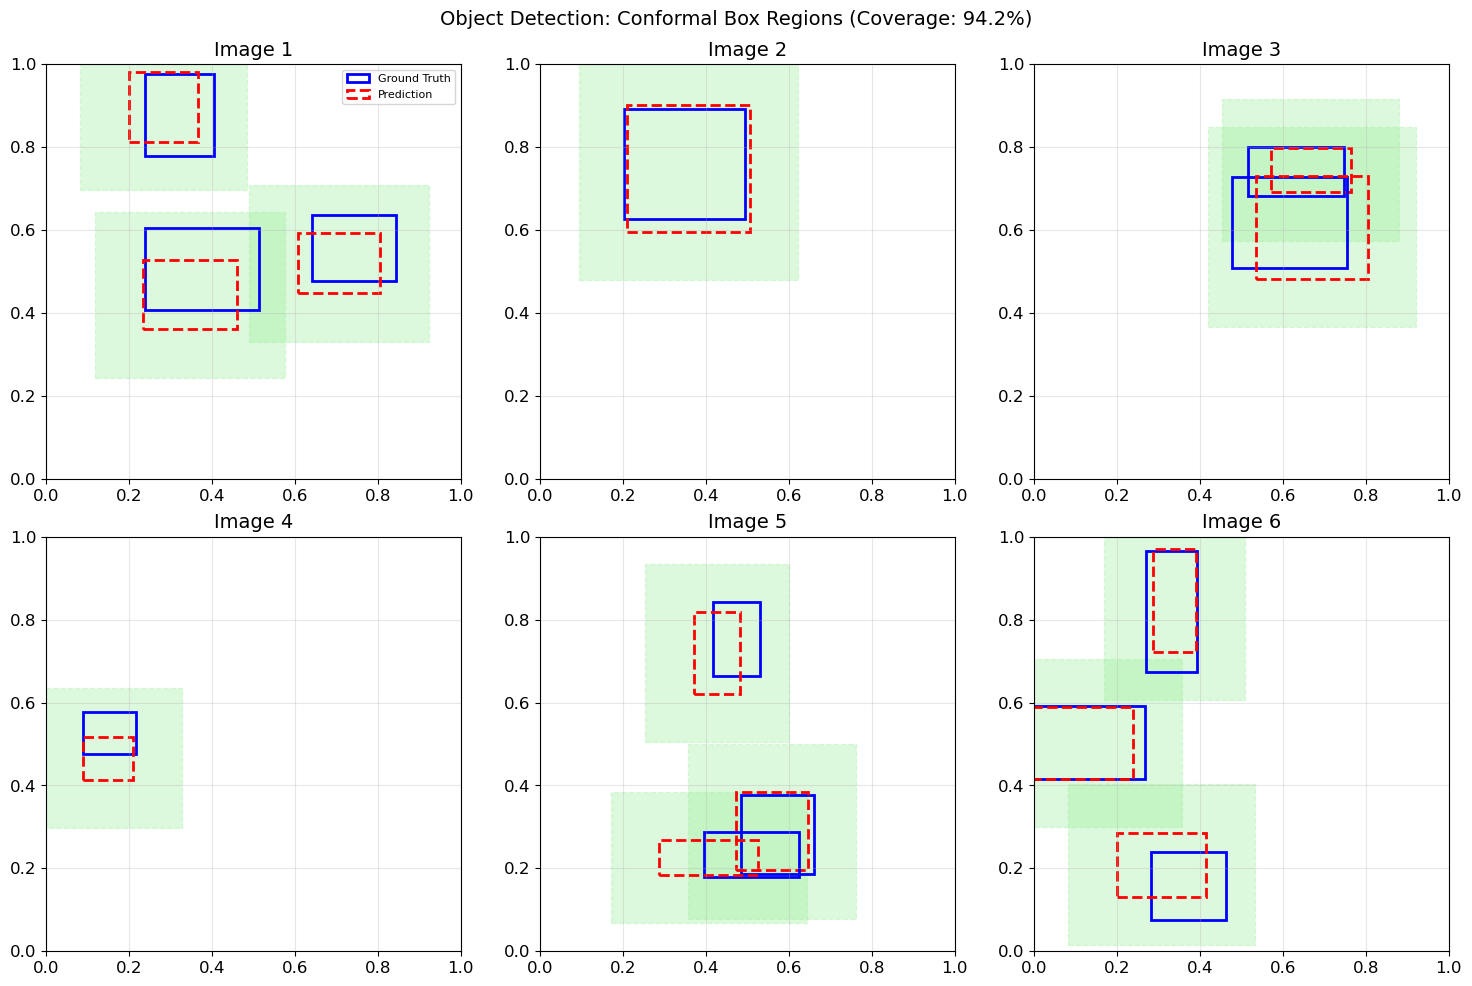


Saved: detection_box_visualization.png

Green shaded regions = conformal uncertainty regions
Blue = ground truth, Red dashed = predictions


In [12]:
# Visualize detection boxes
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

def draw_box(ax, box, color, linestyle='-', linewidth=2, label=None):
    """Draw a box on the axis."""
    x, y, w, h = box
    rect = Rectangle((x - w/2, y - h/2), w, h, 
                     fill=False, edgecolor=color, linestyle=linestyle, 
                     linewidth=linewidth, label=label)
    ax.add_patch(rect)

def draw_conformal_region(ax, conf_box, color='green', alpha=0.2):
    """Draw conformal uncertainty region."""
    x_min, x_max = conf_box['x_range']
    y_min, y_max = conf_box['y_range']
    w_max = conf_box['w_range'][1]
    h_max = conf_box['h_range'][1]
    
    # Draw outer boundary (maximum extent)
    rect = Rectangle(
        (x_min - w_max/2, y_min - h_max/2),
        (x_max - x_min) + w_max,
        (y_max - y_min) + h_max,
        fill=True, facecolor=color, alpha=alpha,
        edgecolor=color, linewidth=1, linestyle='--'
    )
    ax.add_patch(rect)

# Plot 6 example images
for idx, ax in enumerate(axes.flat):
    if idx >= len(gt_test):
        break
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.set_title(f'Image {idx + 1}')
    
    # Draw conformal regions first (background)
    for conf_box in conformal_boxes_test[idx]:
        draw_conformal_region(ax, conf_box, color='lightgreen', alpha=0.3)
    
    # Draw boxes
    for i, (gt_box, pred_box) in enumerate(zip(gt_test[idx], pred_test[idx])):
        draw_box(ax, gt_box, 'blue', linewidth=2, label='Ground Truth' if i == 0 else None)
        draw_box(ax, pred_box, 'red', linestyle='--', linewidth=2, label='Prediction' if i == 0 else None)
    
    if idx == 0:
        ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Object Detection: Conformal Box Regions (Coverage: {coverage_det:.1%})', fontsize=14)
plt.tight_layout()
plt.savefig('detection_box_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: detection_box_visualization.png")
print("\nGreen shaded regions = conformal uncertainty regions")
print("Blue = ground truth, Red dashed = predictions")

### Real Detector Pipeline: IoU Matching

In a real object detection pipeline, the matching process works as follows:

```python
def match_predictions_to_gt(pred_boxes, gt_boxes, iou_threshold=0.5):
    """
    Match predictions to ground truth using IoU.
    
    1. Compute IoU matrix: iou[i, j] = IoU(pred[i], gt[j])
    2. Apply Hungarian algorithm or greedy matching
    3. Only keep matches where IoU >= threshold
    """
    n_pred = len(pred_boxes)
    n_gt = len(gt_boxes)
    
    # Compute IoU matrix
    iou_matrix = np.zeros((n_pred, n_gt))
    for i, pred in enumerate(pred_boxes):
        for j, gt in enumerate(gt_boxes):
            iou_matrix[i, j] = compute_iou(pred, gt)
    
    # Greedy matching (or use scipy.optimize.linear_sum_assignment)
    matches = []
    used_gt = set()
    
    for i in range(n_pred):
        best_j = -1
        best_iou = iou_threshold
        for j in range(n_gt):
            if j not in used_gt and iou_matrix[i, j] > best_iou:
                best_j = j
                best_iou = iou_matrix[i, j]
        
        if best_j >= 0:
            matches.append((i, best_j))
            used_gt.add(best_j)
    
    return matches
```

For conformal calibration, only matched predictions contribute to the calibration scores.

---

# Part 5: LLM/VLM Conformal Prediction

## Multi-Choice QA with Conformal Sets

For multiple-choice QA (e.g., A/B/C/D), we can apply classification conformal prediction:
- Model outputs logits/probabilities for each choice
- Conformal set = choices with probability above threshold

## Abstention Strategy

When the conformal set is too large (low confidence), we can **abstain**:
- Only answer when set size ≤ k (e.g., 1 or 2)
- Trade-off: answer rate vs. error rate

In [13]:
# Simulate LLM multi-choice QA
np.random.seed(RANDOM_SEED + 100)

n_questions = 500
n_choices = 4  # A, B, C, D

# Simulate varying difficulty
# Easy questions: high confidence in correct answer
# Hard questions: low confidence, spread across choices

true_answers = np.random.randint(0, n_choices, n_questions)
difficulty = np.random.beta(2, 2, n_questions)  # 0=easy, 1=hard

# Generate probability vectors
llm_probs = []
for i in range(n_questions):
    # Base probability for correct answer
    correct_prob = 0.9 - 0.6 * difficulty[i]  # Range: 0.3 to 0.9
    
    # Distribute remaining probability
    remaining = 1 - correct_prob
    probs = np.random.dirichlet(np.ones(n_choices - 1)) * remaining
    
    # Insert correct answer probability
    full_probs = np.insert(probs, true_answers[i], correct_prob)
    llm_probs.append(full_probs)

llm_probs = np.array(llm_probs)

# Model predictions (argmax)
llm_predictions = np.argmax(llm_probs, axis=1)
base_accuracy = np.mean(llm_predictions == true_answers)

print("Simulated LLM Multi-Choice QA")
print("=" * 50)
print(f"Questions: {n_questions}")
print(f"Choices: {n_choices} (A, B, C, D)")
print(f"Base accuracy (argmax): {base_accuracy:.1%}")

Simulated LLM Multi-Choice QA
Questions: 500
Choices: 4 (A, B, C, D)
Base accuracy (argmax): 91.6%


In [14]:
# Split into calibration and test
n_cal_llm = 200
probs_cal = llm_probs[:n_cal_llm]
y_cal_llm = true_answers[:n_cal_llm]
probs_test = llm_probs[n_cal_llm:]
y_test_llm = true_answers[n_cal_llm:]

# Apply conformal prediction
def llm_conformal_sets(probs_cal, y_cal, probs_test, alpha):
    """
    Conformal prediction sets for LLM multi-choice QA.
    """
    n_cal = len(y_cal)
    
    # Compute calibration scores (1 - p_true)
    cal_scores = 1 - probs_cal[np.arange(n_cal), y_cal]
    
    # Conformal quantile
    q_hat = conformal_quantile(cal_scores, alpha)
    
    # Construct prediction sets
    prediction_sets = []
    for probs in probs_test:
        pred_set = np.where(probs >= 1 - q_hat)[0].tolist()
        # Ensure at least one element (argmax)
        if len(pred_set) == 0:
            pred_set = [np.argmax(probs)]
        prediction_sets.append(pred_set)
    
    return {
        'prediction_sets': prediction_sets,
        'q_hat': q_hat
    }


# Run for different alpha values
alpha_llm = 0.1
result_llm = llm_conformal_sets(probs_cal, y_cal_llm, probs_test, alpha_llm)

# Evaluate
coverages_llm = [y_test_llm[i] in result_llm['prediction_sets'][i] for i in range(len(y_test_llm))]
set_sizes_llm = [len(s) for s in result_llm['prediction_sets']]

print(f"\nConformal Prediction (α={alpha_llm})")
print("-" * 50)
print(f"Coverage: {np.mean(coverages_llm):.1%}")
print(f"Average set size: {np.mean(set_sizes_llm):.2f}")
print(f"Set size distribution:")
for size in range(1, n_choices + 1):
    count = sum(1 for s in set_sizes_llm if len(result_llm['prediction_sets'][set_sizes_llm.index(s) if s == size else -1]) == size)
    count = set_sizes_llm.count(size)
    print(f"  Size {size}: {count} ({count/len(set_sizes_llm)*100:.1f}%)")


Conformal Prediction (α=0.1)
--------------------------------------------------
Coverage: 93.0%
Average set size: 1.05
Set size distribution:
  Size 1: 286 (95.3%)
  Size 2: 14 (4.7%)
  Size 3: 0 (0.0%)
  Size 4: 0 (0.0%)


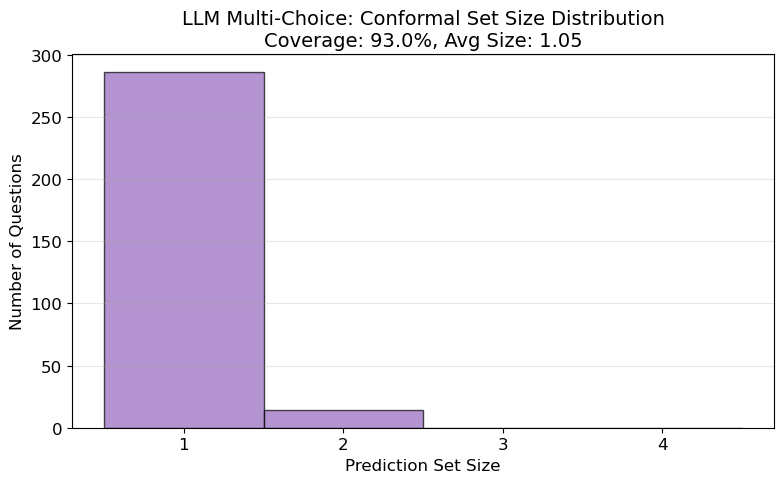


Saved: llm_setsize_histogram.png


In [15]:
# Plot set size histogram
fig, ax = plt.subplots(figsize=(8, 5))

bins = np.arange(0.5, n_choices + 1.5, 1)
ax.hist(set_sizes_llm, bins=bins, edgecolor='black', alpha=0.7, color='tab:purple')
ax.set_xlabel('Prediction Set Size')
ax.set_ylabel('Number of Questions')
ax.set_title(f'LLM Multi-Choice: Conformal Set Size Distribution\nCoverage: {np.mean(coverages_llm):.1%}, Avg Size: {np.mean(set_sizes_llm):.2f}')
ax.set_xticks(range(1, n_choices + 1))
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('llm_setsize_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: llm_setsize_histogram.png")

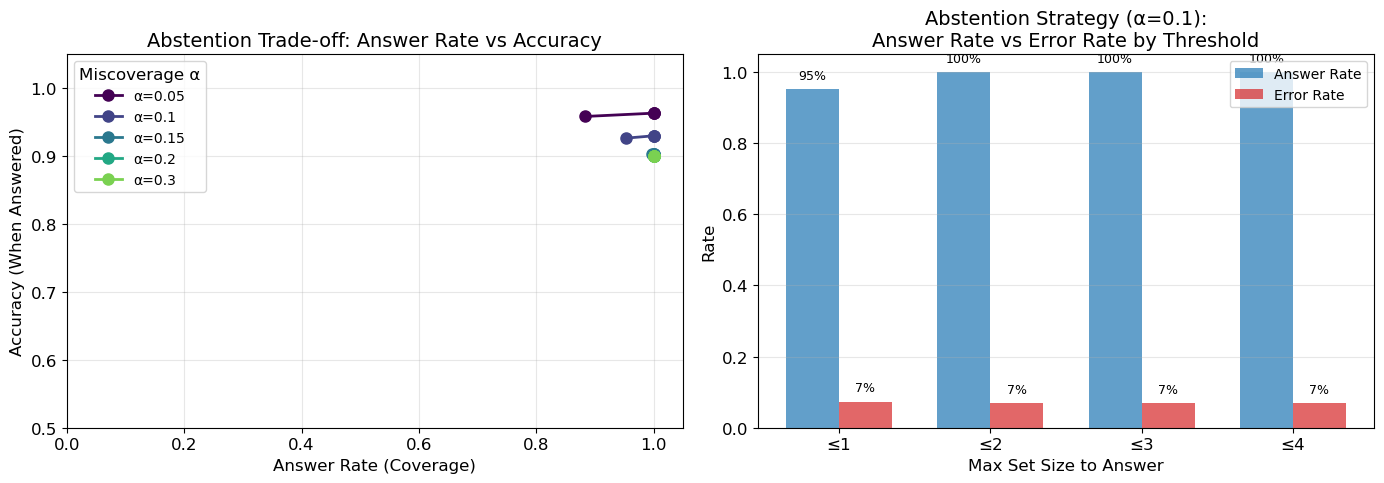


Saved: abstention_tradeoff_curve.png

Key insight: By only answering when set size = 1 (high confidence),
we can significantly reduce error rate at the cost of lower answer rate.


In [16]:
# Abstention analysis
def abstention_analysis(prediction_sets, y_true, max_set_size_to_answer=None):
    """
    Analyze answer rate vs error rate for different abstention thresholds.
    
    Parameters:
    -----------
    prediction_sets : list of lists
        Conformal prediction sets
    y_true : array
        True labels
    max_set_size_to_answer : int or None
        Only answer if set size <= this value
    """
    results = []
    
    for max_size in range(1, 5):  # Set sizes 1, 2, 3, 4
        answered = []
        correct = []
        
        for i, pred_set in enumerate(prediction_sets):
            if len(pred_set) <= max_size:
                answered.append(i)
                # If we answer, we pick the most likely in the set
                # For simplicity, assume first element is most likely
                correct.append(y_true[i] in pred_set)
        
        answer_rate = len(answered) / len(prediction_sets)
        accuracy_when_answered = np.mean(correct) if correct else 0
        error_rate = 1 - accuracy_when_answered
        
        results.append({
            'max_size': max_size,
            'answer_rate': answer_rate,
            'accuracy': accuracy_when_answered,
            'error_rate': error_rate
        })
    
    return results


# Run abstention analysis for different alpha values
alpha_values = [0.05, 0.1, 0.15, 0.2, 0.3]
abstention_results = {}

for alpha_val in alpha_values:
    res = llm_conformal_sets(probs_cal, y_cal_llm, probs_test, alpha_val)
    abstention_results[alpha_val] = abstention_analysis(res['prediction_sets'], y_test_llm)

# Plot abstention tradeoff
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.viridis(np.linspace(0, 0.8, len(alpha_values)))

# Answer rate vs coverage (for set size = 1)
ax = axes[0]
for alpha_val, color in zip(alpha_values, colors):
    results = abstention_results[alpha_val]
    answer_rates = [r['answer_rate'] for r in results]
    accuracies = [r['accuracy'] for r in results]
    ax.plot(answer_rates, accuracies, 'o-', color=color, linewidth=2, markersize=8,
            label=f'α={alpha_val}')

ax.set_xlabel('Answer Rate (Coverage)')
ax.set_ylabel('Accuracy (When Answered)')
ax.set_title('Abstention Trade-off: Answer Rate vs Accuracy')
ax.legend(title='Miscoverage α')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1.05])
ax.set_ylim([0.5, 1.05])

# Detailed view for alpha=0.1
ax = axes[1]
results = abstention_results[0.1]
max_sizes = [r['max_size'] for r in results]
answer_rates = [r['answer_rate'] for r in results]
error_rates = [r['error_rate'] for r in results]

x = np.arange(len(max_sizes))
width = 0.35

bars1 = ax.bar(x - width/2, answer_rates, width, label='Answer Rate', color='tab:blue', alpha=0.7)
bars2 = ax.bar(x + width/2, error_rates, width, label='Error Rate', color='tab:red', alpha=0.7)

ax.set_xlabel('Max Set Size to Answer')
ax.set_ylabel('Rate')
ax.set_title('Abstention Strategy (α=0.1):\nAnswer Rate vs Error Rate by Threshold')
ax.set_xticks(x)
ax.set_xticklabels([f'≤{s}' for s in max_sizes])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, rate in zip(bars1, answer_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{rate:.0%}', ha='center', va='bottom', fontsize=9)
for bar, rate in zip(bars2, error_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{rate:.0%}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('abstention_tradeoff_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: abstention_tradeoff_curve.png")
print("\nKey insight: By only answering when set size = 1 (high confidence),")
print("we can significantly reduce error rate at the cost of lower answer rate.")

---

# Part 6: Distribution Shift and Weighted Conformal

## What Breaks Under Distribution Shift?

The coverage guarantee relies on **exchangeability**. Under distribution shift:

- Test distribution ≠ Calibration distribution
- Exchangeability is violated
- Coverage guarantee no longer holds

## Weighted Conformal Prediction

One approach to handle shift is **weighted conformal prediction**:

$$\hat{q} = \text{Quantile}\left(s_1, ..., s_n; \frac{\sum_{i=1}^{n} w_i \cdot \mathbb{1}[s_i \leq \cdot]}{\sum_i w_i + w_{n+1}}\right)$$

where $w_i$ are importance weights (e.g., likelihood ratios $\frac{p_{test}(x_i)}{p_{cal}(x_i)}$).

**Challenges**:
- Estimating density ratios is hard
- Weights can have high variance
- Requires knowing the nature of the shift

In [17]:
# Demonstrate coverage breakdown under distribution shift
print("Distribution Shift Experiment")
print("=" * 60)

# Original calibration on digits 0-4
# Test on digits 5-9 (shift)

# Split digits by class
X_low = X[y <= 4]
y_low = y[y <= 4]
X_high = X[y >= 5]
y_high = y[y >= 5]

print(f"Low digits (0-4): {len(X_low)} samples")
print(f"High digits (5-9): {len(X_high)} samples")

# Train on all data, calibrate on low, test on both
X_train_shift, X_cal_shift, y_train_shift, y_cal_shift = train_test_split(
    X_low, y_low, test_size=0.3, random_state=RANDOM_SEED
)

# Scale
scaler_shift = StandardScaler()
X_train_shift = scaler_shift.fit_transform(X_train_shift)
X_cal_shift = scaler_shift.transform(X_cal_shift)
X_test_same = scaler_shift.transform(X_low[~np.isin(np.arange(len(X_low)), 
                                                    train_test_split(np.arange(len(X_low)), 
                                                                    test_size=0.3, 
                                                                    random_state=RANDOM_SEED)[1])][:100])
X_test_shift = scaler_shift.transform(X_high[:100])
y_test_same = y_low[~np.isin(np.arange(len(y_low)), 
                              train_test_split(np.arange(len(y_low)), 
                                              test_size=0.3, 
                                              random_state=RANDOM_SEED)[1])][:100]
y_test_shift = y_high[:100]

# Train classifier
clf_shift = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
clf_shift.fit(X_train_shift, y_train_shift)

# Apply conformal prediction
alpha_shift = 0.1

# On same distribution
result_same = split_conformal_classification(clf_shift, X_cal_shift, y_cal_shift, X_test_same, alpha_shift)
cov_same = np.mean([y_test_same[i] in result_same['prediction_sets'][i] for i in range(len(y_test_same))])
size_same = np.mean([len(s) for s in result_same['prediction_sets']])

# On shifted distribution
result_shift = split_conformal_classification(clf_shift, X_cal_shift, y_cal_shift, X_test_shift, alpha_shift)
cov_shift = np.mean([y_test_shift[i] in result_shift['prediction_sets'][i] for i in range(len(y_test_shift))])
size_shift = np.mean([len(s) for s in result_shift['prediction_sets']])

print(f"\nTarget coverage: {1 - alpha_shift:.0%}")
print(f"\n{'Distribution':<25} {'Coverage':>12} {'Avg Size':>12}")
print("-" * 50)
print(f"{'Same (digits 0-4)':<25} {cov_same:>12.1%} {size_same:>12.2f}")
print(f"{'Shifted (digits 5-9)':<25} {cov_shift:>12.1%} {size_shift:>12.2f}")

print("\n⚠️ Coverage breaks down under distribution shift!")
print("The model has never seen digits 5-9, so predictions are unreliable.")

Distribution Shift Experiment
Low digits (0-4): 901 samples
High digits (5-9): 896 samples

Target coverage: 90%

Distribution                  Coverage     Avg Size
--------------------------------------------------
Same (digits 0-4)                93.0%         0.93
Shifted (digits 5-9)              0.0%         0.22

⚠️ Coverage breaks down under distribution shift!
The model has never seen digits 5-9, so predictions are unreliable.


---

# Part 7: Optional - Running Official Repository Examples

This section clones the official conformal prediction repository and runs example code.

**Note**: This requires internet access. If unavailable, skip this section.

In [18]:
# Optional: Clone and explore the official repository
import os
import subprocess

CLONE_REPO = False  # Set to True to clone the repository

if CLONE_REPO:
    repo_url = "https://github.com/aangelopoulos/conformal-prediction.git"
    repo_dir = "conformal-prediction"
    
    if not os.path.exists(repo_dir):
        print(f"Cloning repository: {repo_url}")
        try:
            subprocess.run(["git", "clone", "--depth", "1", repo_url], check=True)
            print("Repository cloned successfully!")
        except subprocess.CalledProcessError as e:
            print(f"Failed to clone repository: {e}")
    else:
        print(f"Repository already exists: {repo_dir}")
    
    # List contents
    if os.path.exists(repo_dir):
        print(f"\nContents of {repo_dir}:")
        for item in sorted(os.listdir(repo_dir)):
            print(f"  {item}")
else:
    print("Repository cloning disabled.")
    print("Set CLONE_REPO = True to clone the official conformal-prediction repository.")
    print("\nRepository: https://github.com/aangelopoulos/conformal-prediction")
    print("\nKey notebooks in the repository:")
    print("  - notebooks/imagenet-smallest-sets.ipynb")
    print("  - notebooks/imagenet-selective-classification.ipynb")
    print("  - notebooks/imagenet-raps.ipynb")

Repository cloning disabled.
Set CLONE_REPO = True to clone the official conformal-prediction repository.

Repository: https://github.com/aangelopoulos/conformal-prediction

Key notebooks in the repository:
  - notebooks/imagenet-smallest-sets.ipynb
  - notebooks/imagenet-selective-classification.ipynb
  - notebooks/imagenet-raps.ipynb


In [19]:
# Reproduce key outputs from the repository (without requiring ImageNet)
# This demonstrates the same methodology on our digits dataset

print("Reproducing Key Results from aangelopoulos/conformal-prediction")
print("=" * 65)
print("\nUsing Digits dataset as a lightweight substitute for ImageNet")

# Run comprehensive analysis similar to the notebooks
# 1. Coverage vs alpha
# 2. Set size vs alpha  
# 3. RAPS lambda sensitivity

# RAPS lambda sensitivity
lambdas = [0, 0.01, 0.05, 0.1, 0.2, 0.5]
alpha_test = 0.1

print(f"\nRAPS Lambda Sensitivity (α={alpha_test})")
print("-" * 50)
print(f"{'Lambda':<10} {'Coverage':>12} {'Avg Size':>12}")
print("-" * 50)

for lam in lambdas:
    res = aps_conformal_prediction(clf, X_cal_scaled, y_cal, X_test_scaled, alpha_test,
                                   method='raps', lambda_reg=lam, k_reg=3)
    cov = np.mean([y_test[i] in res['prediction_sets'][i] for i in range(len(y_test))])
    sizes = np.mean([len(s) for s in res['prediction_sets']])
    print(f"{lam:<10} {cov:>12.1%} {sizes:>12.2f}")

print("\nNote: Higher λ encourages smaller sets at the cost of coverage.")

Reproducing Key Results from aangelopoulos/conformal-prediction

Using Digits dataset as a lightweight substitute for ImageNet

RAPS Lambda Sensitivity (α=0.1)
--------------------------------------------------
Lambda         Coverage     Avg Size
--------------------------------------------------
0                 99.2%         1.24
0.01              99.2%         1.24
0.05              99.2%         1.20
0.1               98.6%         1.18
0.2               99.4%         1.25
0.5               99.2%         1.23

Note: Higher λ encourages smaller sets at the cost of coverage.


---

# Summary

## Key Takeaways

1. **Conformal prediction provides finite-sample, distribution-free coverage guarantees** under exchangeability.

2. **The conformal quantile** is computed as the $\lceil(n+1)(1-\alpha)\rceil$-th order statistic of calibration scores.

3. **For classification**:
   - Simple score: $s = 1 - p_{true}$
   - APS/RAPS: Cumulative probability scores for better efficiency

4. **For regression**:
   - Split conformal: Constant-width intervals
   - CQR: Adaptive intervals via quantile regression

5. **Extensions**:
   - Object detection: Box expansion with conformal quantiles
   - LLM/QA: Prediction sets with abstention strategies

6. **Limitations**:
   - Only marginal coverage (not conditional)
   - Breaks under distribution shift
   - Weighted conformal can partially address shift

---

# Exercises

## Exercise 1: Uniform vs Quantile Binning for Regression

Compare split conformal and CQR on data with different noise structures:
1. Homoscedastic noise (constant variance)
2. Heteroscedastic noise (variance depends on X)
3. Measure coverage and interval width for each
4. When does CQR provide significant benefits?

In [ ]:
# Exercise 1: Starter code
np.random.seed(42)

n = 1000
X_ex1 = np.random.uniform(0, 10, (n, 1))

# TODO: Generate y with homoscedastic noise
# y_homo = f(X) + constant_noise

# TODO: Generate y with heteroscedastic noise  
# y_hetero = f(X) + noise_that_depends_on_X

# TODO: Apply split conformal and CQR to both
# TODO: Compare coverage and interval widths
# TODO: Plot intervals for both cases

print("Exercise 1: Compare conformal methods on different noise structures")
print("Complete the TODO items above.")

## Exercise 2: Distribution Shift Experiment

Systematically evaluate coverage under varying degrees of distribution shift:
1. Create shifted test sets (e.g., different class priors, covariate shift)
2. Measure coverage degradation as shift increases
3. Implement simple weighted conformal and evaluate improvement

In [ ]:
# Exercise 2: Starter code

def create_shifted_test_set(X, y, shift_type='class_imbalance', shift_strength=0.5):
    """
    Create a test set with distribution shift.
    
    shift_type: 'class_imbalance' or 'covariate'
    shift_strength: 0 = no shift, 1 = maximum shift
    """
    # TODO: Implement shift creation
    pass

def weighted_conformal_quantile(scores, weights, alpha):
    """
    Compute weighted conformal quantile.
    
    Uses importance weights to account for distribution shift.
    """
    # TODO: Implement weighted quantile computation
    pass

print("Exercise 2: Distribution shift analysis")
print("Complete the TODO items above.")

## Exercise 3: Mondrian (Class-Conditional) Conformal Prediction

Implement Mondrian conformal prediction:
1. Compute separate conformal quantiles for each class
2. Compare to standard conformal in terms of:
   - Per-class coverage
   - Overall efficiency
3. When is Mondrian beneficial?

In [ ]:
# Exercise 3: Starter code

def mondrian_conformal_classification(clf, X_cal, y_cal, X_test, y_test_pred, alpha):
    """
    Mondrian (class-conditional) conformal prediction.
    
    Computes separate thresholds for each predicted class.
    
    Parameters:
    -----------
    clf : classifier
    X_cal, y_cal : calibration data
    X_test : test features
    y_test_pred : predicted classes for test data (determines which threshold to use)
    alpha : miscoverage rate
    
    Returns:
    --------
    dict with prediction sets and per-class quantiles
    """
    # TODO: Implement Mondrian conformal prediction
    # 1. Group calibration data by true class
    # 2. Compute separate quantile for each class
    # 3. For test points, use quantile of predicted class
    pass

print("Exercise 3: Mondrian conformal prediction")
print("Complete the TODO items above.")

## Exercise 4: Conformal Prediction for Time Series

Adapt conformal prediction for time series forecasting:
1. Why does standard split conformal fail for time series?
2. Implement rolling/adaptive conformal prediction
3. Evaluate on a synthetic AR(1) process

In [ ]:
# Exercise 4: Starter code

def generate_ar1_process(n, phi=0.8, sigma=1.0, seed=42):
    """Generate AR(1) time series: y_t = phi * y_{t-1} + epsilon_t"""
    np.random.seed(seed)
    y = np.zeros(n)
    for t in range(1, n):
        y[t] = phi * y[t-1] + np.random.normal(0, sigma)
    return y

def rolling_conformal_intervals(y, window_size=50, alpha=0.1):
    """
    Rolling conformal prediction intervals for time series.
    
    Uses a sliding window of past residuals for calibration.
    """
    # TODO: Implement rolling conformal prediction
    # 1. At each time t, use past window_size residuals for calibration
    # 2. Compute conformal quantile from these residuals
    # 3. Construct prediction interval for time t
    pass

print("Exercise 4: Time series conformal prediction")
print("Complete the TODO items above.")

---

# Adapting to Your Own Model

## General Recipe

```python
# 1. Define your nonconformity score function
def compute_score(model_output, true_value):
    """
    Score should be:
    - Small when prediction is good
    - Large when prediction is bad
    """
    # Classification: 1 - p_true
    # Regression: |y - y_hat|
    # Detection: max distance between pred and gt boxes
    pass

# 2. Compute calibration scores
cal_scores = [compute_score(model(x), y) for x, y in calibration_set]

# 3. Compute conformal quantile
n = len(cal_scores)
q_level = np.ceil((n + 1) * (1 - alpha)) / n
q_hat = np.quantile(cal_scores, min(q_level, 1.0))

# 4. Construct prediction sets/intervals
def predict_set(x):
    # Include all values y such that score(model(x), y) <= q_hat
    pass
```

---

## References

1. Vovk, Gammerman, Shafer, "Algorithmic Learning in a Random World", 2005
2. Lei et al., "Distribution-Free Predictive Inference For Regression", JASA 2018
3. Romano, Sesia, Candès, "Classification with Valid and Adaptive Coverage", NeurIPS 2020
4. Angelopoulos & Bates, "A Gentle Introduction to Conformal Prediction", 2021
5. Official repository: https://github.com/aangelopoulos/conformal-prediction

In [ ]:
print("\n" + "=" * 60)
print("Notebook Complete!")
print("=" * 60)
print("\nSaved figures:")
print("  - classification_coverage_curve.png")
print("  - classification_setsize_curve.png")
print("  - regression_interval_plot.png")
print("  - detection_box_visualization.png")
print("  - llm_setsize_histogram.png")
print("  - abstention_tradeoff_curve.png")
print("\nKey functions you can reuse:")
print("  - conformal_quantile(scores, alpha)")
print("  - split_conformal_classification(clf, X_cal, y_cal, X_test, alpha)")
print("  - aps_conformal_prediction(clf, X_cal, y_cal, X_test, alpha, method)")
print("  - split_conformal_regression(model, X_cal, y_cal, X_test, alpha)")
print("  - cqr_conformal_regression(X_train, y_train, X_cal, y_cal, X_test, alpha)")
print("  - conformal_box_calibration(gt_cal, pred_cal, alpha)")
print("  - llm_conformal_sets(probs_cal, y_cal, probs_test, alpha)")
print("  - abstention_analysis(prediction_sets, y_true)")